# NL2SQL Pass@K Report

Отчет по режиму `pass_k` на Spider и BIRD для доступного набора моделей `M1` и `M2`.


## 1. Setup And Data Sources

Ниже определяется источник результатов, загружаются raw JSONL и агрегированные метрики, а также создается директория для сохранения фигур.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'notebooks') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from analysis_utils import (
    DATA_DIR,
    compute_sample_outcomes,
    ensure_expert_template,
    get_figures_dir,
    get_results_dir,
    load_records,
    load_summary_metrics,
    reset_analysis_caches,
)

RUN_LABEL = 'pass_k'
FIGURES_DIR = get_figures_dir(RUN_LABEL)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
print(f'Using results directory: {get_results_dir()}')
print(f'Run label: {RUN_LABEL}')
print(f'Data directory: {DATA_DIR}')
print(f'Figures directory: {FIGURES_DIR}')


Using results directory: /home/count/code/vkr/results
Run label: pass_k
Data directory: /home/count/code/vkr/data
Figures directory: /home/count/code/vkr/results/figures/pass_k


In [2]:
reset_analysis_caches()
samples_df, generations_df = load_records(RUN_LABEL)
summary_df = load_summary_metrics(RUN_LABEL).copy()
outcomes_df = compute_sample_outcomes(RUN_LABEL).copy()
expert_path = ensure_expert_template(RUN_LABEL)

print('samples:', samples_df.shape)
print('generations:', generations_df.shape)
print('summary:', summary_df.shape)
print('outcomes:', outcomes_df.shape)
print('expert template/file:', expert_path)

pass_metric_cols = sorted(
    [col for col in summary_df.columns if col.startswith('pass@')],
    key=lambda col: int(col.split('@', 1)[1]),
)
summary_preview_cols = ['model_name', 'benchmark', 'run_label', 'n_samples', 'execution_accuracy', *pass_metric_cols]
summary_df[summary_preview_cols].round(4)


samples: (1000, 14)
generations: (5000, 15)
summary: (10, 18)
outcomes: (1000, 24)
expert template/file: /home/count/code/vkr/results/metrics/pass_k/expert_scores_template.csv


,model_name,benchmark,run_label,n_samples,execution_accuracy,pass@1,pass@3,pass@5
0,Arctic-Text2SQL-R1-7B,bird,pass_k,100,0.19,0.198,0.200,0.20
1,Arctic-Text2SQL-R1-7B,spider,pass_k,100,0.54,0.548,0.562,0.57
2,ChatGPT,bird,pass_k,100,0.27,0.306,0.363,0.38
3,ChatGPT,spider,pass_k,100,0.79,0.792,0.796,0.80
4,DeepSeek,bird,pass_k,100,0.25,0.234,0.291,0.32
5,DeepSeek,spider,pass_k,100,0.78,0.780,0.786,0.79
6,Defog-Llama3-SQLCoder-8B,bird,pass_k,100,0.02,0.020,0.020,0.02
7,Defog-Llama3-SQLCoder-8B,spider,pass_k,100,0.44,0.416,0.452,0.48
8,Hrida-T2SQL,bird,pass_k,100,0.00,0.008,0.010,0.01
9,Hrida-T2SQL,spider,pass_k,100,0.29,0.290,0.320,0.34


## 2. Dataset Overview

Базовые характеристики текущего набора результатов: объем данных, распределение по benchmark и примерная сложность запросов по длине вопроса и SQL.

,n_samples,mean_question_len,median_question_len,mean_gold_sql_len,median_gold_sql_len
benchmark,,,,,
bird,100,123.43,117.5,166.66,164.5
spider,100,64.78,67.0,108.52,89.0


/tmp/ipykernel_378446/1777193041.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=unique_samples, x='benchmark', ax=axes[0, 0], palette='Set2')


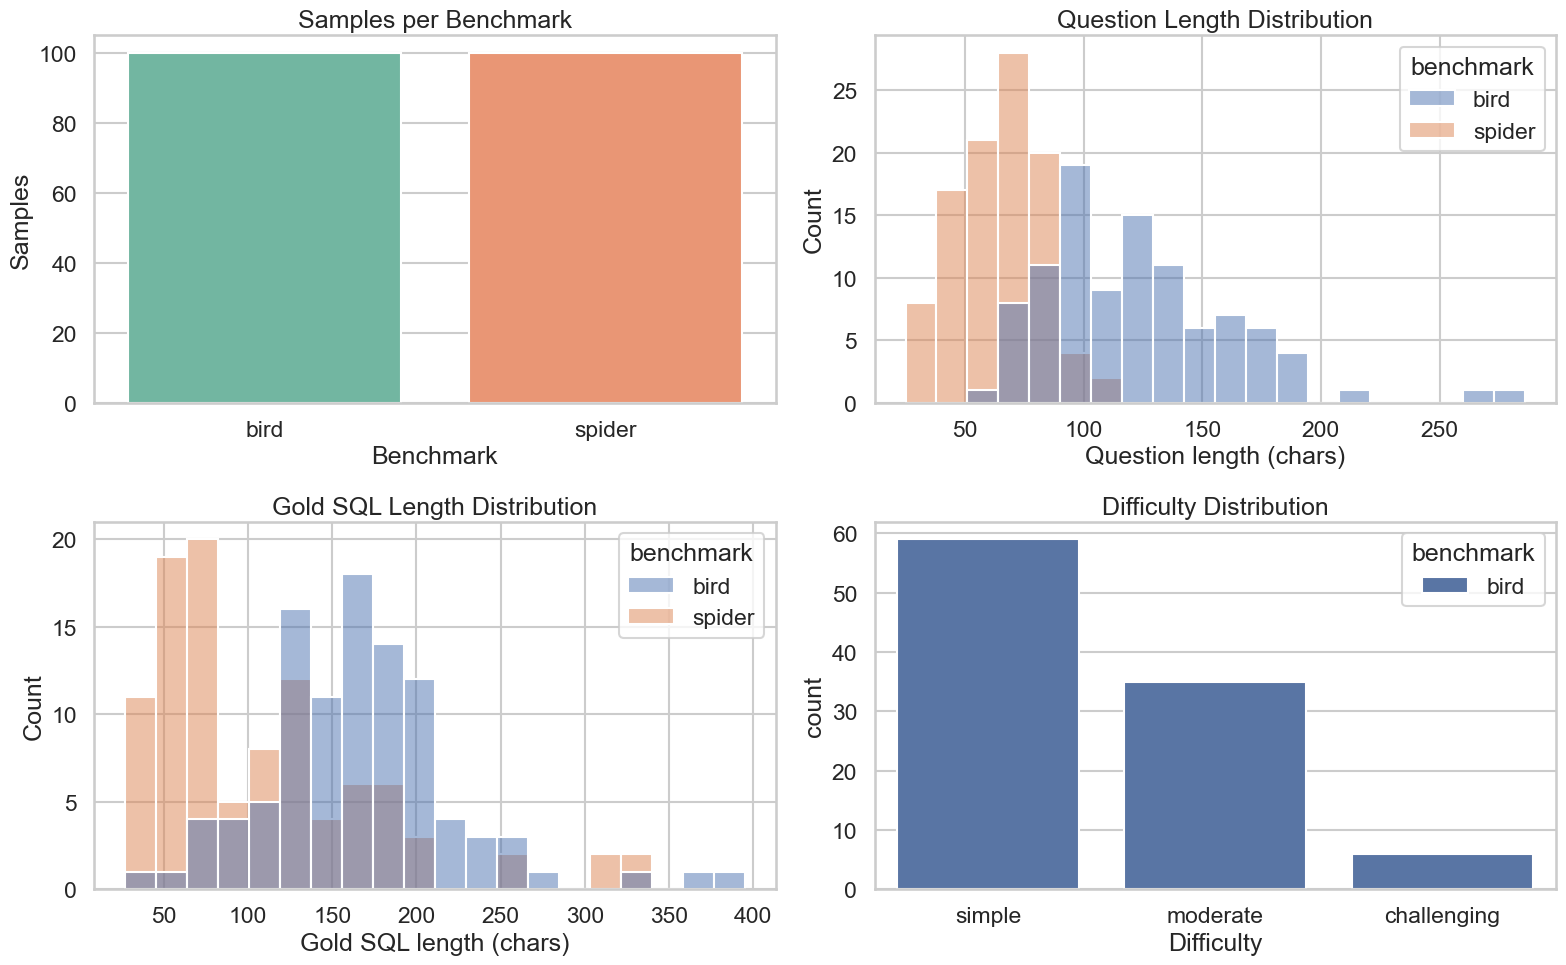

In [3]:
if samples_df.empty:
    raise ValueError('No raw records available.')

unique_samples = (
    samples_df.sort_values(['benchmark', 'sample_id'])
    .drop_duplicates(subset=['benchmark', 'sample_id'])
    .copy()
)

overview = unique_samples.groupby('benchmark').agg(
    n_samples=('sample_id', 'nunique'),
    mean_question_len=('question_len', 'mean'),
    median_question_len=('question_len', 'median'),
    mean_gold_sql_len=('gold_sql_len', 'mean'),
    median_gold_sql_len=('gold_sql_len', 'median'),
)

display(overview.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=unique_samples, x='benchmark', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Samples per Benchmark')
axes[0, 0].set_xlabel('Benchmark')
axes[0, 0].set_ylabel('Samples')

sns.histplot(data=unique_samples, x='question_len', hue='benchmark', bins=20, multiple='layer', ax=axes[0, 1])
axes[0, 1].set_title('Question Length Distribution')
axes[0, 1].set_xlabel('Question length (chars)')

sns.histplot(data=unique_samples, x='gold_sql_len', hue='benchmark', bins=20, multiple='layer', ax=axes[1, 0])
axes[1, 0].set_title('Gold SQL Length Distribution')
axes[1, 0].set_xlabel('Gold SQL length (chars)')

if unique_samples['difficulty'].notna().any():
    difficulty_df = unique_samples.dropna(subset=['difficulty'])
    sns.countplot(data=difficulty_df, x='difficulty', hue='benchmark', ax=axes[1, 1])
    axes[1, 1].set_title('Difficulty Distribution')
    axes[1, 1].set_xlabel('Difficulty')
else:
    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, 'No difficulty labels in current run', ha='center', va='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'report_01_dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Main Results

Основные quality-метрики: `Execution Accuracy` и `Pass@K`. Это главный срез качества генерации SQL.

,model_name,benchmark,execution_accuracy,pass@1,pass@3,pass@5
0,Arctic-Text2SQL-R1-7B,bird,0.19,0.198,0.200,0.20
1,Arctic-Text2SQL-R1-7B,spider,0.54,0.548,0.562,0.57
2,ChatGPT,bird,0.27,0.306,0.363,0.38
3,ChatGPT,spider,0.79,0.792,0.796,0.80
4,DeepSeek,bird,0.25,0.234,0.291,0.32
5,DeepSeek,spider,0.78,0.780,0.786,0.79
6,Defog-Llama3-SQLCoder-8B,bird,0.02,0.020,0.020,0.02
7,Defog-Llama3-SQLCoder-8B,spider,0.44,0.416,0.452,0.48
8,Hrida-T2SQL,bird,0.00,0.008,0.010,0.01
9,Hrida-T2SQL,spider,0.29,0.290,0.320,0.34


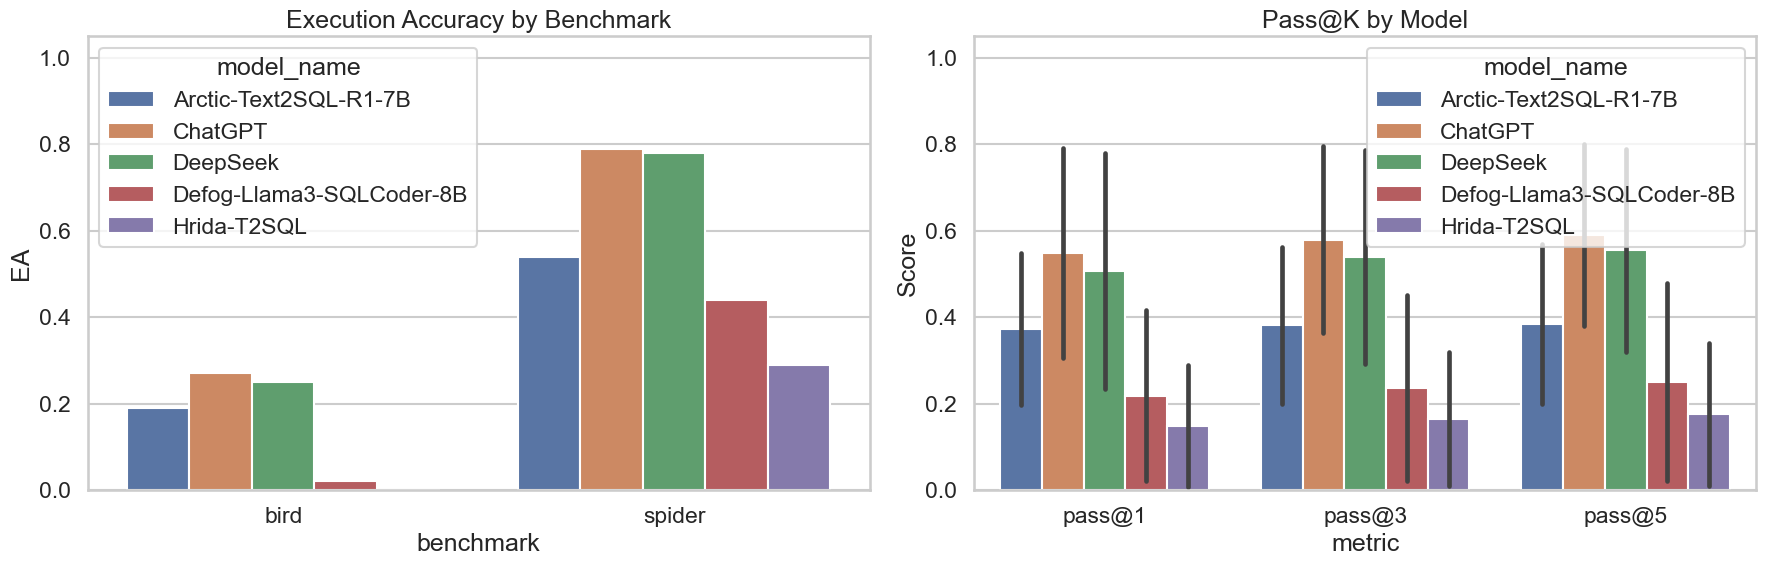

In [4]:
main_metrics = summary_df[['model_name', 'benchmark', 'execution_accuracy', *pass_metric_cols]].copy()
display(main_metrics.round(4))

plot_df = summary_df.melt(
    id_vars=['model_name', 'benchmark'],
    value_vars=['execution_accuracy', *pass_metric_cols],
    var_name='metric',
    value_name='score',
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=summary_df, x='benchmark', y='execution_accuracy', hue='model_name', ax=axes[0])
axes[0].set_title('Execution Accuracy by Benchmark')
axes[0].set_ylabel('EA')
axes[0].set_ylim(0, 1.05)

sns.barplot(data=plot_df[plot_df['metric'] != 'execution_accuracy'], x='metric', y='score', hue='model_name', ax=axes[1])
axes[1].set_title('Pass@K by Model')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'report_02_main_results.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Efficiency

Сравнение по latency, token usage и estimated cost. Этот блок показывает trade-off между качеством и вычислительными затратами.

,model_name,benchmark,Tinf,Tok,Cost,Eff_normalized
0,Arctic-Text2SQL-R1-7B,bird,2123.2226,1186.642,0.0000,NaN
1,Arctic-Text2SQL-R1-7B,spider,1499.8653,448.294,0.0000,NaN
2,ChatGPT,bird,2730.7966,1110.658,0.0022,NaN
3,ChatGPT,spider,1921.0968,381.680,0.0009,NaN
4,DeepSeek,bird,3351.2607,1130.536,0.0003,NaN
5,DeepSeek,spider,2692.3919,415.500,0.0001,NaN
6,Defog-Llama3-SQLCoder-8B,bird,2109.6747,1122.882,0.0000,NaN
7,Defog-Llama3-SQLCoder-8B,spider,1309.4696,388.572,0.0000,NaN
8,Hrida-T2SQL,bird,1111.2875,1522.336,0.0000,NaN
9,Hrida-T2SQL,spider,789.8976,591.286,0.0000,NaN


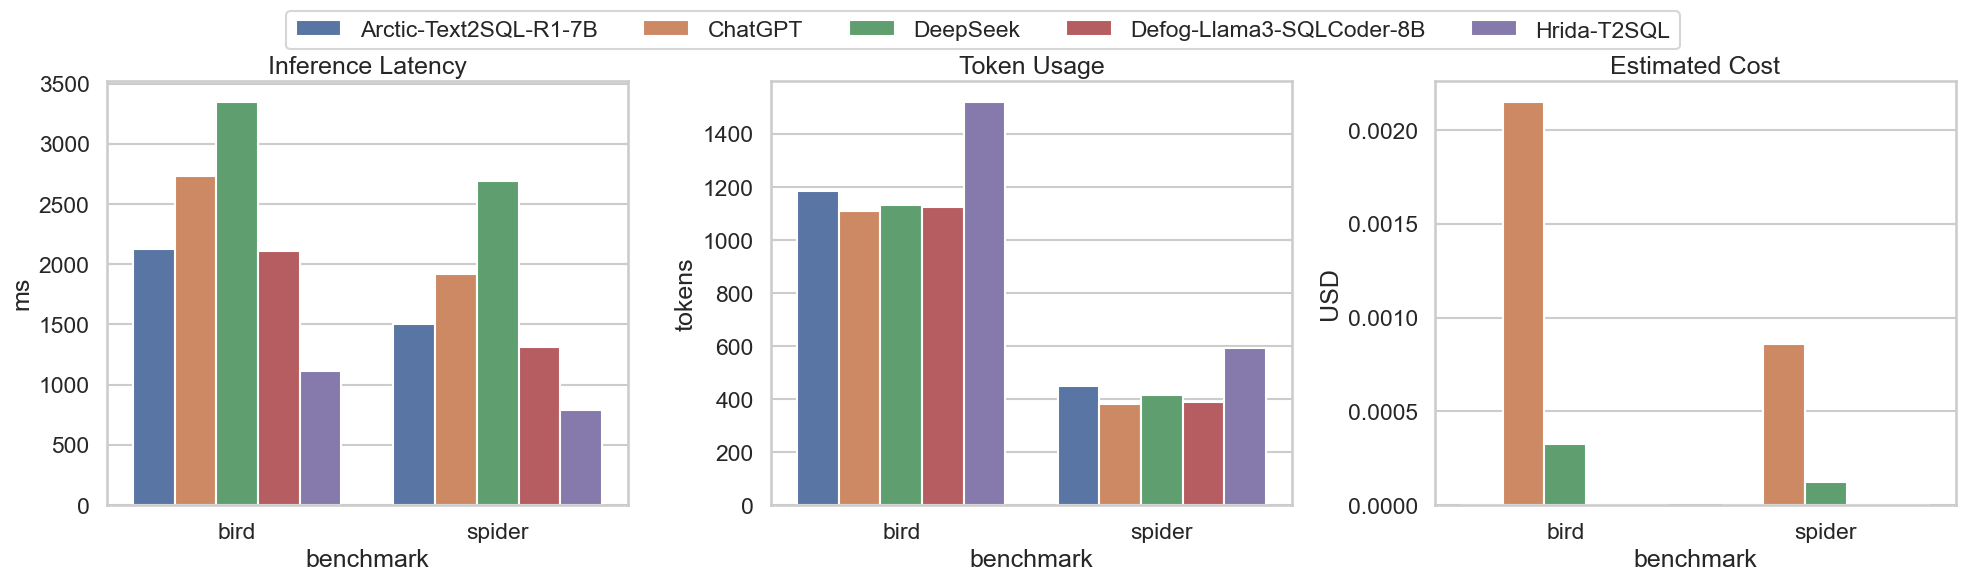

In [5]:
eff_df = summary_df[['model_name', 'benchmark', 'Tinf', 'Tok', 'Cost', 'Eff_normalized']].copy()
display(eff_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=summary_df, x='benchmark', y='Tinf', hue='model_name', ax=axes[0])
axes[0].set_title('Inference Latency')
axes[0].set_ylabel('ms')

sns.barplot(data=summary_df, x='benchmark', y='Tok', hue='model_name', ax=axes[1])
axes[1].set_title('Token Usage')
axes[1].set_ylabel('tokens')

sns.barplot(data=summary_df, x='benchmark', y='Cost', hue='model_name', ax=axes[2])
axes[2].set_title('Estimated Cost')
axes[2].set_ylabel('USD')

for ax in axes:
    ax.legend_.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels))

plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(FIGURES_DIR / 'report_03_efficiency_components.png', dpi=300, bbox_inches='tight')
plt.show()

if summary_df['Eff_normalized'].notna().any():
    plt.figure(figsize=(8, 5))
    sns.barplot(data=summary_df, x='benchmark', y='Eff_normalized', hue='model_name')
    plt.title('Normalized Efficiency Score')
    plt.ylabel('Eff_normalized')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'report_04_efficiency_score.png', dpi=300, bbox_inches='tight')
    plt.show()


## 5. Hypothesis-Driven Comparison

Парное сравнение моделей на уровне sample. Здесь видно среднюю разницу в accuracy и bootstrap confidence interval по benchmark.

,benchmark,left_model,right_model,pair,left_accuracy,right_accuracy,accuracy_diff,ci_low,ci_high,left_only_correct,right_only_correct
0,bird,Arctic-Text2SQL-R1-7B,ChatGPT,Arctic-Text2SQL-R1-7B vs ChatGPT,0.19,0.27,-0.08,-0.18,0.0100,7,15
1,bird,Arctic-Text2SQL-R1-7B,DeepSeek,Arctic-Text2SQL-R1-7B vs DeepSeek,0.19,0.25,-0.06,-0.15,0.0400,9,15
2,bird,Arctic-Text2SQL-R1-7B,Defog-Llama3-SQLCoder-8B,Arctic-Text2SQL-R1-7B vs Defog-Llama3-SQLCoder-8B,0.19,0.02,0.17,0.10,0.2600,18,1
3,bird,Arctic-Text2SQL-R1-7B,Hrida-T2SQL,Arctic-Text2SQL-R1-7B vs Hrida-T2SQL,0.19,0.00,0.19,0.12,0.2700,19,0
4,bird,ChatGPT,DeepSeek,ChatGPT vs DeepSeek,0.27,0.25,0.02,-0.08,0.1200,12,10
5,bird,ChatGPT,Defog-Llama3-SQLCoder-8B,ChatGPT vs Defog-Llama3-SQLCoder-8B,0.27,0.02,0.25,0.16,0.3400,26,1
6,bird,ChatGPT,Hrida-T2SQL,ChatGPT vs Hrida-T2SQL,0.27,0.00,0.27,0.18,0.3600,27,0
7,bird,DeepSeek,Defog-Llama3-SQLCoder-8B,DeepSeek vs Defog-Llama3-SQLCoder-8B,0.25,0.02,0.23,0.15,0.3200,24,1
8,bird,DeepSeek,Hrida-T2SQL,DeepSeek vs Hrida-T2SQL,0.25,0.00,0.25,0.16,0.3300,25,0
9,bird,Defog-Llama3-SQLCoder-8B,Hrida-T2SQL,Defog-Llama3-SQLCoder-8B vs Hrida-T2SQL,0.02,0.00,0.02,0.00,0.0500,2,0


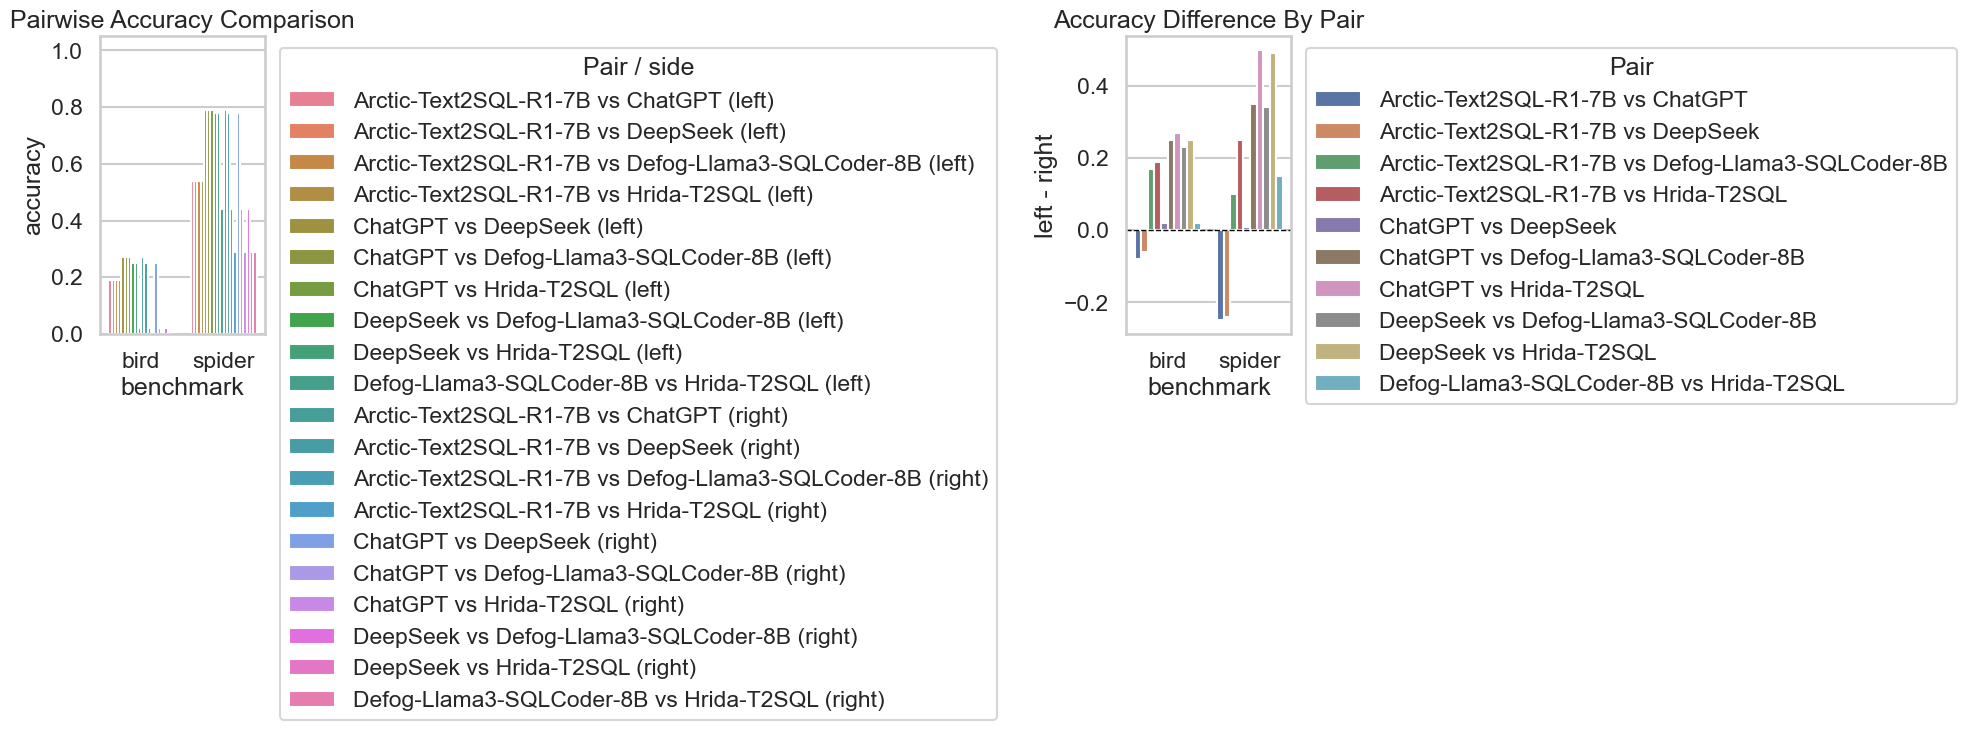

In [6]:
from itertools import combinations

rows = []
for benchmark, group in outcomes_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_name', values='first_hit', aggfunc='first')
    model_names = list(pivot.columns)
    if len(model_names) < 2:
        continue

    for left, right in combinations(model_names, 2):
        left_vals = pivot[left].fillna(False).astype(bool)
        right_vals = pivot[right].fillna(False).astype(bool)
        diff = float(left_vals.mean() - right_vals.mean())

        diffs = []
        if len(pivot) > 1:
            pair_df = pd.DataFrame({'left': left_vals, 'right': right_vals})
            for _ in range(1000):
                sample = pair_df.sample(n=len(pair_df), replace=True)
                diffs.append(float(sample['left'].mean() - sample['right'].mean()))
            ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
        else:
            ci_low = ci_high = diff

        rows.append({
            'benchmark': benchmark,
            'left_model': left,
            'right_model': right,
            'pair': f'{left} vs {right}',
            'left_accuracy': float(left_vals.mean()),
            'right_accuracy': float(right_vals.mean()),
            'accuracy_diff': diff,
            'ci_low': float(ci_low),
            'ci_high': float(ci_high),
            'left_only_correct': int((left_vals & ~right_vals).sum()),
            'right_only_correct': int((~left_vals & right_vals).sum()),
        })

hyp_df = pd.DataFrame(rows)
display(hyp_df.round(4))

if not hyp_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    plot_df = hyp_df.melt(
        id_vars=['benchmark', 'pair'],
        value_vars=['left_accuracy', 'right_accuracy'],
        var_name='side',
        value_name='accuracy',
    )
    plot_df['pair_side'] = plot_df['pair'] + " (" + plot_df['side'].str.replace('_accuracy', '', regex=False) + ")"
    sns.barplot(data=plot_df, x='benchmark', y='accuracy', hue='pair_side', ax=axes[0])
    axes[0].set_title('Pairwise Accuracy Comparison')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(title='Pair / side', bbox_to_anchor=(1.02, 1), loc='upper left')

    sns.barplot(data=hyp_df, x='benchmark', y='accuracy_diff', hue='pair', ax=axes[1])
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Accuracy Difference By Pair')
    axes[1].set_ylabel('left - right')
    axes[1].legend(title='Pair', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'report_05_hypothesis.png', dpi=300, bbox_inches='tight')
    plt.show()


## 6. Error Analysis

Разбор sample-level ошибок: типы промахов, overlap между моделями и примеры неуспешных предсказаний.

,sample_id,benchmark,model_name,error_category,first_pred_error
0,bird_10,bird,Arctic-Text2SQL-R1-7B,result_mismatch,NaN
1,bird_9,bird,Arctic-Text2SQL-R1-7B,execution_error,incomplete input
2,bird_8,bird,Arctic-Text2SQL-R1-7B,execution_error,no such column: FRPM_Count_k_12
3,bird_12,bird,Arctic-Text2SQL-R1-7B,correct,NaN
4,bird_21,bird,Arctic-Text2SQL-R1-7B,execution_error,You can only execute one statement at a time.


/tmp/ipykernel_378446/2275339625.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


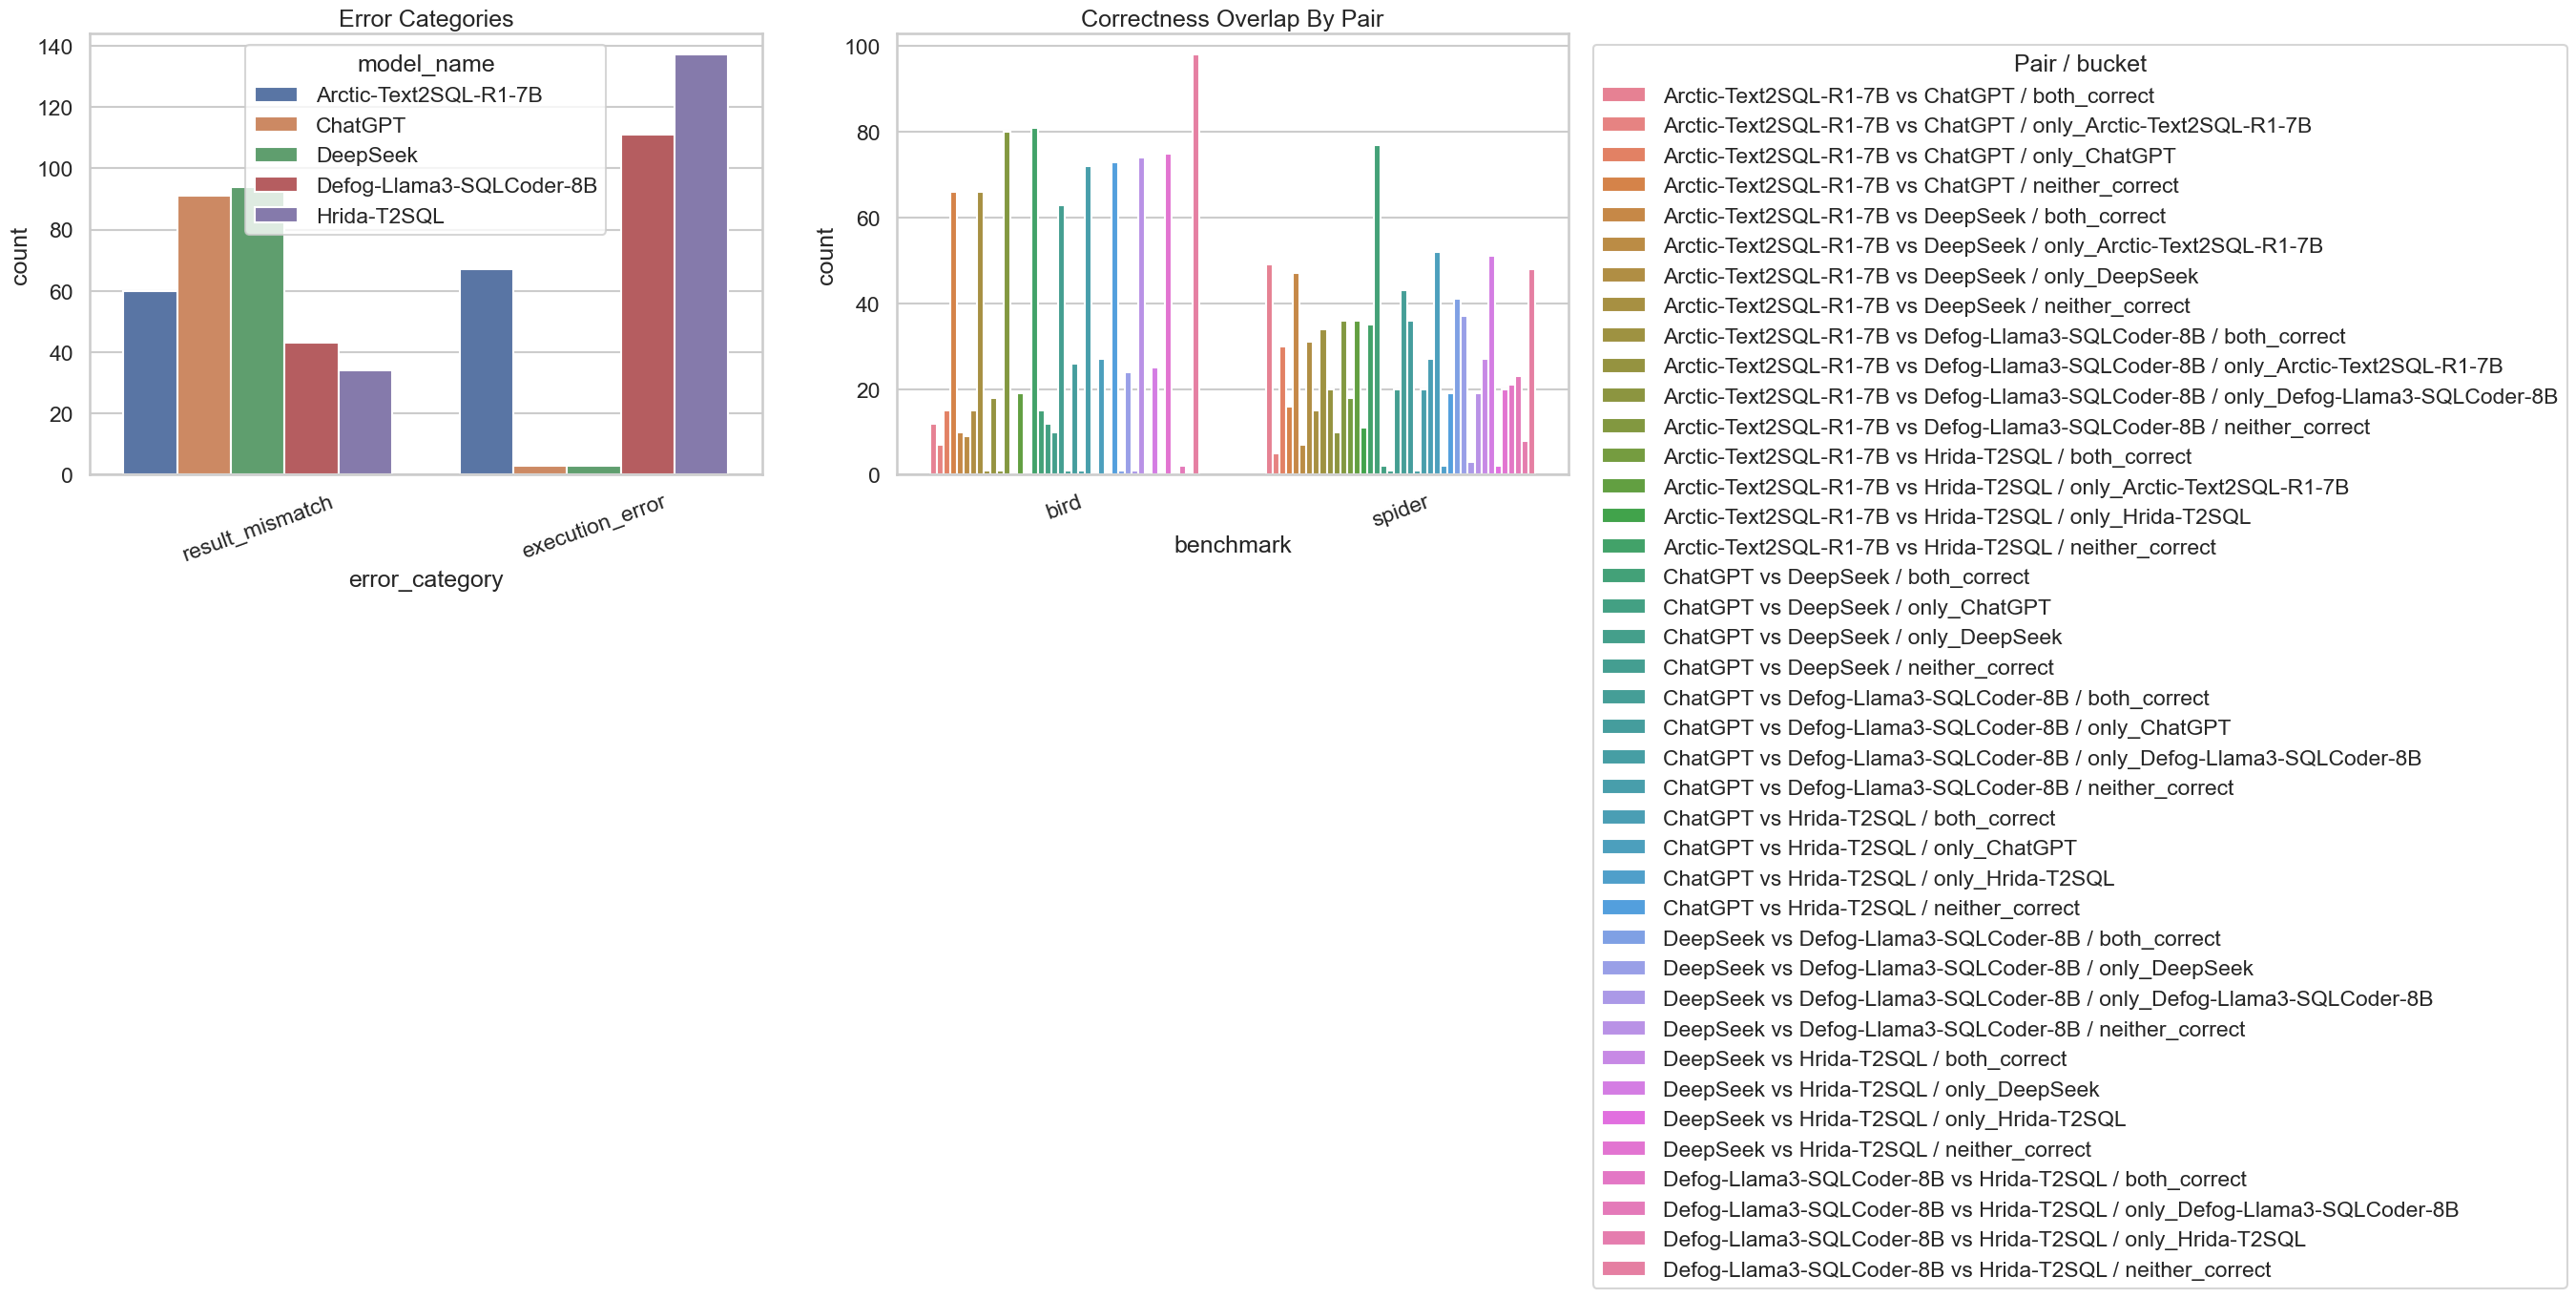

,benchmark,model_name,sample_id,question,gold_sql,first_pred_sql,error_category,first_pred_error
0,bird,Arctic-Text2SQL-R1-7B,bird_10,For the school with the highest average score ...,SELECT T2.`FRPM Count (Ages 5-17)` FROM satsco...,SELECT T1.`FRPM Count (Ages 5-17)` FROM frpm A...,result_mismatch,NaN
1,bird,Arctic-Text2SQL-R1-7B,bird_9,Among the schools with the average score in Ma...,SELECT COUNT(T2.`School Code`) FROM satscores ...,SELECT COUNT(*) FROM schools WHERE CDSCode IN ...,execution_error,incomplete input
2,bird,Arctic-Text2SQL-R1-7B,bird_8,What is the number of SAT test takers of the s...,SELECT NumTstTakr FROM satscores WHERE cds = (...,SELECT NumTstTakr FROM satscores WHERE cds IN ...,execution_error,no such column: FRPM_Count_k_12
4,bird,Arctic-Text2SQL-R1-7B,bird_21,In Los Angeles how many schools have more than...,SELECT COUNT(CDSCode) FROM frpm WHERE `County ...,SELECT COUNT(*) FROM frpm WHERE `County Name` ...,execution_error,You can only execute one statement at a time.
5,bird,Arctic-Text2SQL-R1-7B,bird_24,Give the names of the schools with the percent...,SELECT T2.`School Name` FROM satscores AS T1 I...,The question asks for school names where 'Perc...,execution_error,"near ""The"": syntax error"
6,bird,Arctic-Text2SQL-R1-7B,bird_25,Name schools in Riverside which the average of...,"SELECT T1.sname, T2.`Charter Funding Type` FRO...","SELECT T1.School, T1.FundingType FROM schools ...",execution_error,misuse of aggregate: AVG()
7,bird,Arctic-Text2SQL-R1-7B,bird_3,What is the unabbreviated mailing street addre...,SELECT T2.MailStreet FROM frpm AS T1 INNER JOI...,SELECT T1.MailStreet FROM schools AS T1 INNER ...,execution_error,no such column: T2.FRPM_Count_K_12
8,bird,Arctic-Text2SQL-R1-7B,bird_11,Please list the codes of the schools with a to...,SELECT T2.CDSCode FROM schools AS T1 INNER JOI...,SELECT DISTINCT cds FROM satscores WHERE enrol...,result_mismatch,NaN
9,bird,Arctic-Text2SQL-R1-7B,bird_26,State the names and full communication address...,"SELECT T1.`School Name`, T2.Street, T2.City, T...",The question asks for high schools within Mont...,execution_error,"near ""The"": syntax error"
10,bird,Arctic-Text2SQL-R1-7B,bird_22,Which school in Contra Costa has the highest n...,SELECT sname FROM satscores WHERE cname = 'Con...,SELECT s.School FROM schools AS s INNER JOIN s...,result_mismatch,NaN


In [7]:
from itertools import combinations

def categorize(row):
    if row['first_hit']:
        return 'correct'
    if row['empty_sql']:
        return 'empty_sql'
    if not row['first_pred_success']:
        return 'execution_error'
    return 'result_mismatch'

error_df = outcomes_df.copy()
error_df['error_category'] = error_df.apply(categorize, axis=1)

display(error_df[['sample_id', 'benchmark', 'model_name', 'error_category', 'first_pred_error']].head())

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

failures = error_df[error_df['error_category'] != 'correct'].copy()
if failures.empty:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'No failures in current run', ha='center', va='center')
else:
    sns.countplot(data=failures, x='error_category', hue='model_name', ax=axes[0])
    axes[0].set_title('Error Categories')
    axes[0].tick_params(axis='x', rotation=20)

comparison_rows = []
for benchmark, group in error_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_name', values='first_hit', aggfunc='first')
    model_names = list(pivot.columns)
    if len(model_names) < 2:
        continue
    for left, right in combinations(model_names, 2):
        left_vals = pivot[left].fillna(False).astype(bool)
        right_vals = pivot[right].fillna(False).astype(bool)
        comparison_rows.extend([
            {'benchmark': benchmark, 'pair': f'{left} vs {right}', 'bucket': 'both_correct', 'count': int((left_vals & right_vals).sum())},
            {'benchmark': benchmark, 'pair': f'{left} vs {right}', 'bucket': f'only_{left}', 'count': int((left_vals & ~right_vals).sum())},
            {'benchmark': benchmark, 'pair': f'{left} vs {right}', 'bucket': f'only_{right}', 'count': int((~left_vals & right_vals).sum())},
            {'benchmark': benchmark, 'pair': f'{left} vs {right}', 'bucket': 'neither_correct', 'count': int((~left_vals & ~right_vals).sum())},
        ])

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Not enough models for overlap analysis', ha='center', va='center')
else:
    comparison_df['pair_bucket'] = comparison_df['pair'] + " / " + comparison_df['bucket']
    sns.barplot(data=comparison_df, x='benchmark', y='count', hue='pair_bucket', ax=axes[1])
    axes[1].set_title('Correctness Overlap By Pair')
    axes[1].legend(title='Pair / bucket', bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'report_06_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

error_examples = failures[[
    'benchmark', 'model_name', 'sample_id', 'question', 'gold_sql', 'first_pred_sql', 'error_category', 'first_pred_error'
]].head(20)
error_examples


## 7. Expert Score Placeholder

Если экспертная разметка заполнена, здесь будет удобно агрегировать `completeness / efficiency / readability`. Пока ноутбук показывает расположение шаблона и coverage по заполнению.

,sample_id,model_name,benchmark,completeness,efficiency,readability,is_scored
0,bird_10,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,False
1,bird_9,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,False
2,bird_8,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,False
3,bird_12,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,False
4,bird_21,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,False


,benchmark,model_name,scored_rows,total_rows,coverage
0,bird,Arctic-Text2SQL-R1-7B,0,100,0.0
1,bird,ChatGPT,0,100,0.0
2,bird,DeepSeek,0,100,0.0
3,bird,Defog-Llama3-SQLCoder-8B,0,100,0.0
4,bird,Hrida-T2SQL,0,100,0.0
5,spider,Arctic-Text2SQL-R1-7B,0,100,0.0
6,spider,ChatGPT,0,100,0.0
7,spider,DeepSeek,0,100,0.0
8,spider,Defog-Llama3-SQLCoder-8B,0,100,0.0
9,spider,Hrida-T2SQL,0,100,0.0


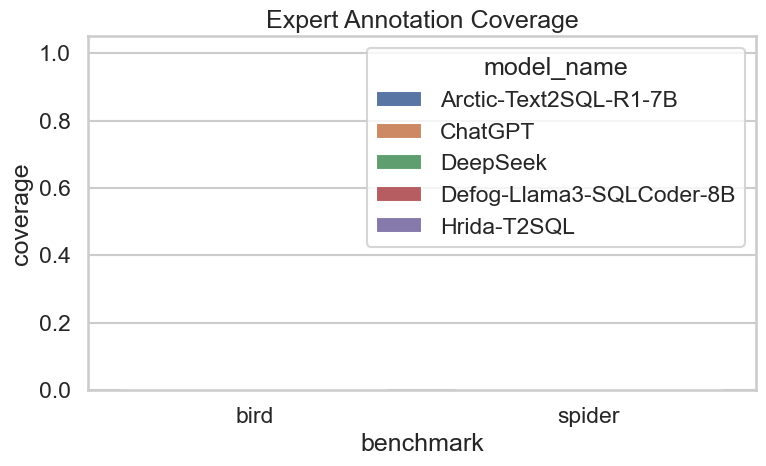

In [8]:
expert_df = pd.read_csv(expert_path) if Path(expert_path).exists() else pd.DataFrame()
score_cols = ['completeness', 'efficiency', 'readability']
for col in score_cols:
    if col not in expert_df.columns:
        expert_df[col] = pd.NA

expert_df['is_scored'] = expert_df[score_cols].notna().all(axis=1) if not expert_df.empty else pd.Series(dtype=bool)
display(expert_df.head())

if not expert_df.empty:
    coverage = (
        expert_df.groupby(['benchmark', 'model_name'])['is_scored']
        .agg(['sum', 'count'])
        .reset_index()
        .rename(columns={'sum': 'scored_rows', 'count': 'total_rows'})
    )
    coverage['coverage'] = coverage['scored_rows'] / coverage['total_rows'].clip(lower=1)
    display(coverage.round(3))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=coverage, x='benchmark', y='coverage', hue='model_name')
    plt.title('Expert Annotation Coverage')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'report_07_expert_coverage.png', dpi=300, bbox_inches='tight')
    plt.show()


## 8. Conclusions

Краткий итог по текущему набору результатов: основное качество, вычислительная стоимость и наблюдаемые различия между моделями.

In [9]:
final_pass_col = pass_metric_cols[-1] if pass_metric_cols else None
conclusion_cols = ['model_name', 'benchmark', 'execution_accuracy', 'Tinf', 'Tok', 'Cost']
if final_pass_col is not None:
    conclusion_cols.insert(3, final_pass_col)
conclusions = summary_df[conclusion_cols].copy()
conclusions = conclusions.sort_values(['benchmark', 'execution_accuracy'], ascending=[True, False])
conclusions.round(4)


,model_name,benchmark,execution_accuracy,pass@5,Tinf,Tok,Cost
2,ChatGPT,bird,0.27,0.38,2730.7966,1110.658,0.0022
4,DeepSeek,bird,0.25,0.32,3351.2607,1130.536,0.0003
0,Arctic-Text2SQL-R1-7B,bird,0.19,0.20,2123.2226,1186.642,0.0000
6,Defog-Llama3-SQLCoder-8B,bird,0.02,0.02,2109.6747,1122.882,0.0000
8,Hrida-T2SQL,bird,0.00,0.01,1111.2875,1522.336,0.0000
3,ChatGPT,spider,0.79,0.80,1921.0968,381.680,0.0009
5,DeepSeek,spider,0.78,0.79,2692.3919,415.500,0.0001
1,Arctic-Text2SQL-R1-7B,spider,0.54,0.57,1499.8653,448.294,0.0000
7,Defog-Llama3-SQLCoder-8B,spider,0.44,0.48,1309.4696,388.572,0.0000
9,Hrida-T2SQL,spider,0.29,0.34,789.8976,591.286,0.0000
